In [1]:
import os
import math
import time
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus = torch.cuda.device_count()
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}  |  GPUs: {n_gpus}')
for i in range(n_gpus):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

PyTorch : 2.9.0+cu126
Device  : cuda  |  GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## Config

In [ ]:
IMG_SIZE    = 224
PATCH_SIZE  = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2   # 196
MASK_RATIO  = 0.75
NUM_VISIBLE = int(NUM_PATCHES * (1 - MASK_RATIO))  # 49
NUM_MASKED  = NUM_PATCHES - NUM_VISIBLE             # 147
PATCH_DIM   = PATCH_SIZE * PATCH_SIZE * 3           # 768

# Encoder ViT-Base B/16
ENC_DIM, ENC_LAYERS, ENC_HEADS, ENC_MLP = 768, 12, 12, 4

# Decoder ViT-Small S/16
DEC_DIM, DEC_LAYERS, DEC_HEADS, DEC_MLP = 384, 12, 6, 4

# Regularisation
DROP_RATE     = 0.1

# Training
EPOCHS        = 35
BATCH_SIZE    = 64
BASE_LR       = 1.5e-4
WEIGHT_DECAY  = 0.05
WARMUP_EPOCHS = 5
GRAD_CLIP     = 1.0

# Early stopping
ES_PATIENCE   = 7   

DATA_ROOT   = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'
NUM_WORKERS = 4

print(f'Patches: {NUM_PATCHES}  |  Visible: {NUM_VISIBLE}  |  Masked: {NUM_MASKED}')
print(f'Enc dim: {ENC_DIM}      |  Dec dim: {DEC_DIM}')
print(f'Dropout: {DROP_RATE}    |  Early stop patience: {ES_PATIENCE}')

Patches: 196  |  Visible: 49  |  Masked: 147
Enc dim: 768      |  Dec dim: 384
Dropout: 0.1    |  Early stop patience: 7


## Dataset & DataLoaders

In [17]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# TinyImageNet val split stores all images flat with a .txt annotation file
class TinyImageNetVal(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        img_dir  = os.path.join(root, 'val', 'images')
        ann_file = os.path.join(root, 'val', 'val_annotations.txt')
        classes  = sorted(os.listdir(os.path.join(root, 'train')))
        cls2idx  = {c: i for i, c in enumerate(classes)}
        self.img_paths, self.labels = [], []
        with open(ann_file) as f:
            for line in f:
                p = line.strip().split('\t')
                self.img_paths.append(os.path.join(img_dir, p[0]))
                self.labels.append(cls2idx.get(p[1], 0))

    def __len__(self): return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]


train_dataset = ImageFolder(os.path.join(DATA_ROOT, 'train'), transform=train_transform)
val_dataset   = TinyImageNetVal(DATA_ROOT, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_dataset):,}  |  Val: {len(val_dataset):,}')

Train: 100,000  |  Val: 10,000


## Patchification & Masking

In [ ]:
def patchify(images, patch_size=PATCH_SIZE):
    """(B,C,H,W) -> (B, N, P*P*C)"""
    B, C, H, W = images.shape
    h, w = H // patch_size, W // patch_size
    x = images.reshape(B, C, h, patch_size, w, patch_size)
    x = x.permute(0, 2, 4, 3, 5, 1).reshape(B, h * w, patch_size * patch_size * C)
    return x


def unpatchify(patches, patch_size=PATCH_SIZE, img_size=IMG_SIZE):
    """(B, N, P*P*C) -> (B, C, H, W)"""
    B, N, _ = patches.shape
    h = w = img_size // patch_size
    x = patches.reshape(B, h, w, patch_size, patch_size, 3)
    x = x.permute(0, 5, 1, 3, 2, 4).reshape(B, 3, img_size, img_size)
    return x


def random_masking(x, mask_ratio=MASK_RATIO):
    
    B, N, D = x.shape
    num_keep    = int(N * (1 - mask_ratio))
    noise       = torch.rand(B, N, device=x.device)
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    ids_keep    = ids_shuffle[:, :num_keep]
    x_visible   = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))
    mask        = torch.ones(B, N, device=x.device)
    mask[:, :num_keep] = 0
    mask        = torch.gather(mask, 1, ids_restore)
    return x_visible, mask, ids_restore


dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
assert torch.allclose(dummy, unpatchify(patchify(dummy))), 'Roundtrip failed'
print(f'patchify shape : {patchify(dummy).shape}')   # (2, 196, 768)
print('Roundtrip OK')

patchify shape : torch.Size([2, 196, 768])
Roundtrip OK


## Building Blocks

In [19]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, num_heads, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(dim, dim * 3)
        self.proj      = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = self.attn_drop((q @ k.transpose(-2, -1)) * self.scale).softmax(dim=-1)
        x = self.proj_drop(self.proj((attn @ v).transpose(1, 2).reshape(B, N, C)))
        return x


class MLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4, drop=0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim * mlp_ratio), nn.GELU(), nn.Dropout(drop),
            nn.Linear(dim * mlp_ratio, dim), nn.Dropout(drop),
        )
    def forward(self, x): return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4, drop=0., attn_drop=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = MultiHeadSelfAttention(dim, num_heads, attn_drop, drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = MLP(dim, mlp_ratio, drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


print('MultiHeadSelfAttention, MLP, TransformerBlock defined')

MultiHeadSelfAttention, MLP, TransformerBlock defined


## 2D Sinusoidal Positional Embedding

Positional embedding shape: (196, 768)


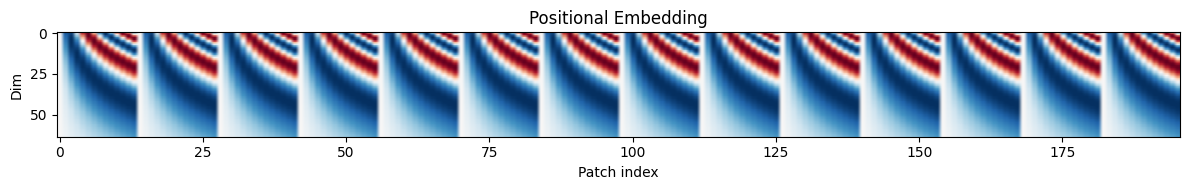

In [20]:
def get_2d_sincos_pos_embed(embed_dim, grid_size, cls_token=False):
    grid = np.stack(np.meshgrid(
        np.arange(grid_size, dtype=np.float32),
        np.arange(grid_size, dtype=np.float32)
    ), axis=0).reshape(2, 1, grid_size, grid_size)

    half = embed_dim // 4
    def encode(pos):
        omega = 1.0 / (10000 ** (np.arange(half, dtype=np.float32) / half))
        out   = np.einsum('n,d->nd', pos.reshape(-1), omega)
        return np.concatenate([np.sin(out), np.cos(out)], axis=1)

    emb = np.concatenate([encode(grid[0]), encode(grid[1])], axis=1)  # (G^2, D)
    if cls_token:
        emb = np.concatenate([np.zeros((1, embed_dim), dtype=np.float32), emb], axis=0)
    return emb


pe = get_2d_sincos_pos_embed(ENC_DIM, IMG_SIZE // PATCH_SIZE)
print(f'Positional embedding shape: {pe.shape}')  # (196, 768)

plt.figure(figsize=(12, 2))
plt.imshow(pe[:, :64].T, aspect='auto', cmap='RdBu')
plt.title('Positional Embedding')
plt.xlabel('Patch index'); plt.ylabel('Dim')
plt.tight_layout(); plt.show()

## MAE Encoder

In [ ]:
class MAEEncoder(nn.Module):
    
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=3,
                 embed_dim=ENC_DIM, depth=ENC_LAYERS, num_heads=ENC_HEADS,
                 mlp_ratio=ENC_MLP, mask_ratio=MASK_RATIO, drop=DROP_RATE):
        super().__init__()
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        G = img_size // patch_size

        self.patch_embed = nn.Linear(patch_size * patch_size * in_chans, embed_dim)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, embed_dim))

        pe = get_2d_sincos_pos_embed(embed_dim, G, cls_token=True)
        self.register_buffer('pos_embed', torch.from_numpy(pe).float().unsqueeze(0))

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, drop=drop) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, images):
        x = self.patch_embed(patchify(images, self.patch_size))  
        x = x + self.pos_embed[:, 1:, :]                         # positional embed before masking
        x, mask, ids_restore = random_masking(x, self.mask_ratio)
        cls = (self.cls_token + self.pos_embed[:, :1, :]).expand(x.size(0), -1, -1)
        x   = torch.cat([cls, x], dim=1)
        for blk in self.blocks: x = blk(x)
        return self.norm(x), mask, ids_restore


enc = MAEEncoder()
print(f'Encoder params: {sum(p.numel() for p in enc.parameters())/1e6:.1f} M  (target ~86 M)')
with torch.no_grad():
    lat, msk, ids = enc(torch.randn(2, 3, IMG_SIZE, IMG_SIZE))
print(f'Latent: {lat.shape}  |  Mask: {msk.shape}  |  ids_restore: {ids.shape}')

Encoder params: 85.6 M  (target ~86 M)
Latent: torch.Size([2, 50, 768])  |  Mask: torch.Size([2, 196])  |  ids_restore: torch.Size([2, 196])


## MAE Decoder

In [ ]:
class MAEDecoder(nn.Module):
    
    def __init__(self, num_patches=NUM_PATCHES, encoder_dim=ENC_DIM,
                 decoder_dim=DEC_DIM, depth=DEC_LAYERS, num_heads=DEC_HEADS,
                 mlp_ratio=DEC_MLP, patch_size=PATCH_SIZE, in_chans=3, img_size=IMG_SIZE,
                 drop=DROP_RATE):
        super().__init__()
        self.num_patches = num_patches
        self.patch_dim   = patch_size * patch_size * in_chans

        self.proj       = nn.Linear(encoder_dim, decoder_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))

        G  = img_size // patch_size
        pe = get_2d_sincos_pos_embed(decoder_dim, G, cls_token=True)
        self.register_buffer('pos_embed', torch.from_numpy(pe).float().unsqueeze(0))

        self.blocks = nn.ModuleList([
            TransformerBlock(decoder_dim, num_heads, mlp_ratio, drop=drop) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(decoder_dim)
        self.pred = nn.Linear(decoder_dim, self.patch_dim)
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, latent, ids_restore):
        B     = latent.size(0)
        x     = self.proj(latent)                          
        N_vis = x.size(1) - 1
        N_msk = self.num_patches - N_vis

        # Append mask tokens and restore original spatial order
        x_full = torch.cat([x[:, 1:, :],
                            self.mask_token.expand(B, N_msk, -1)], dim=1)
        x_full = torch.gather(x_full, 1,
                    ids_restore.unsqueeze(-1).expand(-1, -1, x_full.size(-1)))

        x = torch.cat([x[:, :1, :], x_full], dim=1) + self.pos_embed
        for blk in self.blocks: x = blk(x)
        return self.pred(self.norm(x)[:, 1:, :])           


dec = MAEDecoder()
print(f'Decoder params: {sum(p.numel() for p in dec.parameters())/1e6:.1f} M  (target ~22 M)')
with torch.no_grad():
    pred = dec(lat, ids)
print(f'Pred shape: {pred.shape}')   # (2, 196, 768)

Decoder params: 21.9 M  (target ~22 M)
Pred shape: torch.Size([2, 196, 768])


## Full MAE Model

In [ ]:
class MaskedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = MAEEncoder()
        self.decoder = MAEDecoder()

    def compute_loss(self, images, pred_patches, mask):
        """MSE on masked patches only. Targets are per-patch normalised."""
        target = patchify(images)
        mean   = target.mean(dim=-1, keepdim=True)
        var    = target.var(dim=-1, keepdim=True)
        target = (target - mean) / (var + 1e-6).sqrt()
        loss   = ((pred_patches - target) ** 2).mean(dim=-1)  
        return (loss * mask).sum() / mask.sum()

    def forward(self, images):
        latent, mask, ids_restore = self.encoder(images)
        pred = self.decoder(latent, ids_restore)
        loss = self.compute_loss(images, pred, mask)
        return loss, pred, mask


model = MaskedAutoencoder()
if n_gpus > 1:
    model = nn.DataParallel(model)
    print(f'DataParallel across {n_gpus} GPUs')
model = model.to(device)

print(f'Total MAE params: {sum(p.numel() for p in model.parameters())/1e6:.1f} M')

with torch.no_grad():
    _loss, _, _ = model(torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device))
    _loss = _loss.mean()  
print(f'Forward pass OK — loss: {_loss.item():.4f}')

DataParallel across 2 GPUs
Total MAE params: 107.5 M
Forward pass OK — loss: 1.1558


## Optimiser, Scheduler & AMP

In [ ]:
effective_lr = BASE_LR * BATCH_SIZE / 256

no_decay = {'bias', 'LayerNorm.weight', 'norm.weight'}
param_groups = [
    {'params': [p for n, p in model.named_parameters()
                if not any(nd in n for nd in no_decay) and p.requires_grad],
     'weight_decay': WEIGHT_DECAY},
    {'params': [p for n, p in model.named_parameters()
                if     any(nd in n for nd in no_decay) and p.requires_grad],
     'weight_decay': 0.0},
]
optimizer = torch.optim.AdamW(param_groups, lr=effective_lr, betas=(0.9, 0.95))

total_steps  = EPOCHS * len(train_loader)
warmup_steps = WARMUP_EPOCHS * len(train_loader)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = GradScaler()

print(f'Effective LR : {effective_lr:.2e}')
print(f'Total steps  : {total_steps:,}  |  Warmup: {warmup_steps:,}')

Effective LR : 3.75e-05
Total steps  : 54,670  |  Warmup: 7,810


## Training Loop

In [25]:
from tqdm.auto import tqdm

train_losses, val_losses = [], []
best_val    = float('inf')
es_counter  = 0

print(f'Training MAE for {EPOCHS} epochs  |  Early stop patience: {ES_PATIENCE}\n')

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # Training
    model.train()
    running = 0.0
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS} [Train]', leave=False)
    for imgs, _ in train_bar:
        imgs = imgs.to(device, non_blocking=True)
        with autocast():
            loss, _, _ = model(imgs)
            loss = loss.mean()
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        running += loss.item()
        train_bar.set_postfix(loss=f'{loss.item():.4f}', lr=f'{scheduler.get_last_lr()[0]:.2e}')

    avg_train = running / len(train_loader)
    train_losses.append(avg_train)

    # Validation
    model.eval()
    val_running = 0.0
    val_bar = tqdm(val_loader, desc=f'Epoch {epoch}/{EPOCHS} [Val]  ', leave=False)
    with torch.no_grad():
        for imgs, _ in val_bar:
            imgs = imgs.to(device, non_blocking=True)
            with autocast():
                loss, _, _ = model(imgs)
                loss = loss.mean()
            val_running += loss.item()
            val_bar.set_postfix(loss=f'{loss.item():.4f}')

    avg_val = val_running / len(val_loader)
    val_losses.append(avg_val)

    flag = ''
    if avg_val < best_val:
        best_val   = avg_val
        es_counter = 0
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'val_loss': best_val}, 'mae_best.pth')
        flag = ' <- best'
    else:
        es_counter += 1
        if es_counter >= ES_PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {ES_PATIENCE} epochs)')
            break

    print(f'Epoch {epoch:>3}/{EPOCHS} | Train: {avg_train:.6f} | Val: {avg_val:.6f} | '
          f'LR: {scheduler.get_last_lr()[0]:.2e} | Time: {time.time()-t0:.1f}s{flag}')

print(f'\nDone. Best val loss: {best_val:.6f}')

Training MAE for 35 epochs  |  Early stop patience: 7



Epoch 1/35 [Train]:   0%|          | 0/1562 [00:00<?, ?it/s]

Epoch 1/35 [Val]  :   0%|          | 0/157 [00:00<?, ?it/s]

Epoch   1/35 | Train: 0.866449 | Val: 0.740002 | LR: 7.50e-06 | Time: 579.1s <- best


Epoch 2/35 [Train]:   0%|          | 0/1562 [00:00<?, ?it/s]

...

Epoch 34/35 [Val]  :   0%|          | 0/157 [00:00<?, ?it/s]

Epoch  34/35 | Train: 0.384190 | Val: 0.381979 | LR: 1.03e-07 | Time: 610.5s


Epoch 35/35 [Train]:   0%|          | 0/1562 [00:00<?, ?it/s]

Epoch 35/35 [Val]  :   0%|          | 0/157 [00:00<?, ?it/s]

Epoch  35/35 | Train: 0.384337 | Val: 0.381628 | LR: 0.00e+00 | Time: 611.7s <- best

Done. Best val loss: 0.381628


## Training Loss Plot

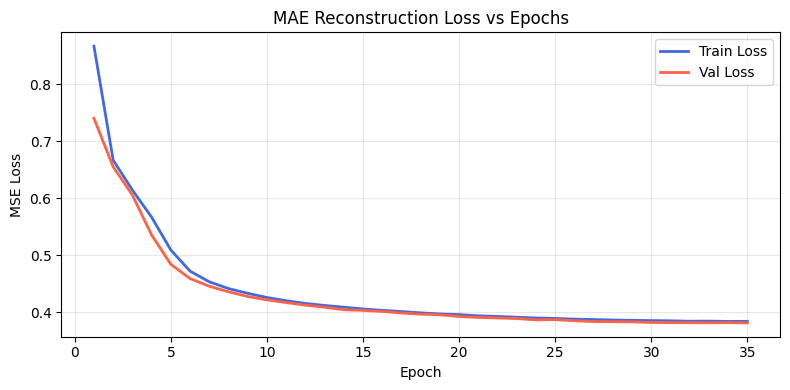

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', color='royalblue', lw=2)
plt.plot(range(1, len(val_losses)   + 1), val_losses,   label='Val Loss',   color='tomato',    lw=2)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('MAE Reconstruction Loss vs Epochs')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 13 — Visualisation Utilities

In [ ]:
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalise(t):
    img = (t.cpu().float() * STD + MEAN).clamp(0, 1)
    return (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)


def make_masked_image(image, mask, patch_size=PATCH_SIZE, img_size=IMG_SIZE):
    w   = img_size // patch_size
    out = denormalise(image).copy().astype(float)
    for idx in range(mask.size(0)):
        if mask[idx] == 1:
            r = (idx // w) * patch_size; c = (idx % w) * patch_size
            out[r:r+patch_size, c:c+patch_size] = 127
    return out.astype(np.uint8)


def reconstruct_image(pred_patches, original, mask):
    orig_p = patchify(original.unsqueeze(0)).squeeze(0)
    mean   = orig_p.mean(dim=-1, keepdim=True)
    var    = orig_p.var(dim=-1, keepdim=True)
    pred_d = pred_patches * (var + 1e-6).sqrt() + mean
    comp   = torch.where(mask.unsqueeze(-1).bool(), pred_d, orig_p)
    return denormalise(unpatchify(comp.unsqueeze(0)).squeeze(0))


print('Visualisation utilities defined')

## Reconstruction (5 Samples)

In [ ]:
ckpt = torch.load('mae_best.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded checkpoint — epoch {ckpt["epoch"]}, val_loss={ckpt["val_loss"]:.6f}')

NUM_DISPLAY = 5
imgs_batch, _ = next(iter(val_loader))
imgs_batch = imgs_batch[:NUM_DISPLAY].to(device)

with torch.no_grad():
    with autocast():
        _, preds, masks = model(imgs_batch)

preds    = preds.float().cpu()
masks    = masks.float().cpu()
imgs_cpu = imgs_batch.float().cpu()

fig, axes = plt.subplots(NUM_DISPLAY, 3, figsize=(12, 4 * NUM_DISPLAY))
for col, title in enumerate(['Masked Input (75% removed)', 'MAE Reconstruction', 'Original Ground Truth']):
    axes[0, col].set_title(title, fontsize=13, fontweight='bold')

for i in range(NUM_DISPLAY):
    arrs = [
        make_masked_image(imgs_cpu[i], masks[i]),
        reconstruct_image(preds[i], imgs_cpu[i], masks[i]),
        denormalise(imgs_cpu[i]),
    ]
    for col, arr in enumerate(arrs):
        axes[i, col].imshow(arr)
        axes[i, col].axis('off')
    axes[i, 0].set_ylabel(f'Sample {i+1}', fontsize=11, rotation=0, labelpad=50, va='center')

plt.suptitle('MAE Qualitative Reconstruction', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reconstruction_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Quantitative Evaluation: PSNR & SSIM

In [29]:
from tqdm.auto import tqdm

psnr_scores, ssim_scores = [], []
EVAL_BATCHES = 20

model.eval()
with torch.no_grad():
    for i, (imgs, _) in enumerate(tqdm(val_loader, total=EVAL_BATCHES)):
        if i >= EVAL_BATCHES: break
        imgs = imgs.to(device)
        with autocast():
            _, preds, masks = model(imgs)
        preds = preds.float().cpu()
        masks = masks.float().cpu()
        imgs  = imgs.float().cpu()
        for j in range(imgs.size(0)):
            recon = reconstruct_image(preds[j], imgs[j], masks[j])
            orig  = denormalise(imgs[j])
            psnr_scores.append(psnr_fn(orig, recon, data_range=255))
            ssim_scores.append(ssim_fn(orig, recon, data_range=255, channel_axis=2))

mean_psnr, std_psnr = np.mean(psnr_scores), np.std(psnr_scores)
mean_ssim, std_ssim = np.mean(ssim_scores), np.std(ssim_scores)

print('=' * 42)
print(f'  Samples : {len(psnr_scores):,}')
print(f'  PSNR    : {mean_psnr:.2f} +/- {std_psnr:.2f} dB')
print(f'  SSIM    : {mean_ssim:.4f} +/- {std_ssim:.4f}')
print('=' * 42)

print(f'\n{"Sample":>8} | {"PSNR (dB)":>10} | {"SSIM":>8}')
print('-' * 32)
for i in range(min(5, len(psnr_scores))):
    print(f'{i+1:>8} | {psnr_scores[i]:>10.2f} | {ssim_scores[i]:>8.4f}')

  0%|          | 0/20 [00:00<?, ?it/s]

  Samples : 1,280
  PSNR    : 24.20 +/- 3.04 dB
  SSIM    : 0.7117 +/- 0.0964

  Sample |  PSNR (dB) |     SSIM
--------------------------------
       1 |      20.52 |   0.6309
       2 |      27.88 |   0.7753
       3 |      23.91 |   0.7703
       4 |      29.54 |   0.8925
       5 |      22.14 |   0.6521
